# Imputing a reconstructible categorical column: penguin `sex`

We knock out ~30% of the `sex` column of the Palmer **penguins** table, fill it two ways — a
`LanguageModelImputer` and a `KNNImputer` — then ask two things: how well does each recover the
hidden cells, and does the imputed `sex` help a downstream RandomForest predict `species`?

The imputer fills a missing cell by conditioning on the row's observed cells, drawing from
$p(\text{sex} \mid \text{the rest})$ (see `00-intro.ipynb`). A categorical cell is **scored** over
its observed levels and filled with the most likely one — the argmax, exactly how the classifier
ranks `classes_`. `KNNImputer` can't score levels: it ordinal-encodes the categoricals, averages
the neighbours' codes, and rounds back to a level.

`species` — the dataset's natural classification target — is **held out of the imputation** (using a
label to fill a feature is leakage you can't reproduce at test time), so `sex` is imputed from the
body measurements and `island` only. Penguins are sexually dimorphic (males are larger), so `sex` is
genuinely reconstructible from those columns — the question is which method recovers it, and whether
that recovery carries downstream.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder

from sklm import GenerationConfig, LanguageModelImputer, LoRAConfig, TrainingConfig

sns.set_theme(style='whitegrid', context='notebook')
SEED = 42

## Data: `species` held out, ~30% of `sex` knocked out

`penguins` is 333 complete rows — numeric `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
`body_mass_g` and categorical `island`, `sex`, `species`. We hold `species` aside as the downstream
target and impute `sex` from the rest, knocking out ~30% of its cells (keeping the truth to score
the reconstruction).

In [2]:
NUM = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
CAT = ['island', 'sex']  # `species` is held out as the downstream label
target_col = 'sex'

penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)
penguins[CAT + ['species']] = penguins[CAT + ['species']].astype(str)
frame = penguins[NUM + CAT]  # the imputation table — no `species`
y_species = penguins['species']  # held-out downstream target
sex_levels = sorted(frame[target_col].unique())

rng = np.random.default_rng(SEED)
mask = rng.random(len(frame)) < 0.30
corrupt = frame.copy()
corrupt.loc[mask, target_col] = np.nan
print(f'missing {target_col} cells: {int(mask.sum())} of {len(frame)}  (`species` held out as the label)')

missing sex cells: 104 of 333  (`species` held out as the label)


## Impute `sex` with the language model

`fit_transform` fine-tunes once on the observed cells and fills every `NaN`; the categorical `sex`
is scored over its two levels and filled with the argmax. `loss_on_target_only` focuses the
fine-tuning loss on the imputed column, and the column order is permuted each epoch so the model
learns `p(sex | the rest)` from many orderings.

In [3]:
lm_filled = LanguageModelImputer(
    model='gabfssilva/distilgpt2',
    backend='mlx',
    precision='fp32',
    lora=LoRAConfig(),
    generation=GenerationConfig(n_samples=6, candidate_scoring='sum'),
    training=TrainingConfig(
        epochs=50,
        batch_size=16,
        augmentation_factor=8,
        loss_on_target_only=True,
    ),
    random_state=SEED,
).fit_transform(corrupt)

HTML(value='')

## Baseline: KNN over ordinal-encoded columns

`KNNImputer` needs a numeric matrix, so the baseline ordinal-encodes the categoricals, imputes by
the 5 nearest neighbours, and rounds the codes back to levels. `knn_impute` wraps that round-trip so
it returns a filled frame just like the imputer above — same input, same shape.

In [4]:
def knn_impute(frame: pd.DataFrame, cat_cols: list[str], k: int = 5) -> pd.DataFrame:
    enc = OrdinalEncoder().fit(frame[cat_cols])
    filled = frame.copy()
    filled[cat_cols] = enc.transform(frame[cat_cols])
    filled[:] = KNNImputer(n_neighbors=k).fit_transform(filled.to_numpy(float))
    filled[cat_cols] = enc.inverse_transform(filled[cat_cols].round().to_numpy(copy=True))
    return filled


knn_filled = knn_impute(corrupt, CAT)

## Reconstruction accuracy on the hidden cells

Both methods produced a full frame; we pull the imputed `sex` at the hidden cells and compare to the
truth, against the majority-class rate as a floor.

In [5]:
truth = frame.loc[mask, target_col].to_numpy()
lm_pred = lm_filled.loc[mask, target_col].to_numpy()
knn_pred = knn_filled.loc[mask, target_col].to_numpy()
base_rate = float(frame[target_col].value_counts(normalize=True).max())

for name, pred in [('language model', lm_pred), ('KNN baseline', knn_pred)]:
    acc = float((pred == truth).mean())
    print(f'{name:16}  accuracy {acc:.3f}   error-rate {1 - acc:.3f}')
label = 'majority floor'
print(f'{label:16}  accuracy {base_rate:.3f}')

language model    accuracy 0.846   error-rate 0.154
KNN baseline      accuracy 0.740   error-rate 0.260
majority floor    accuracy 0.505


## `sex` is genuinely reconstructible — and the language model recovers more of it

With `species` held out, `sex` still carries a clear signal in the body measurements (sexual
dimorphism) and `island`, so both methods beat the majority floor — unlike a column whose only strong
predictor is held out, which would collapse to a single level. The language model scores each level
under the fitted conditional and pulls ahead of KNN, whose ordinal-encode-average-round discards the
categorical structure.

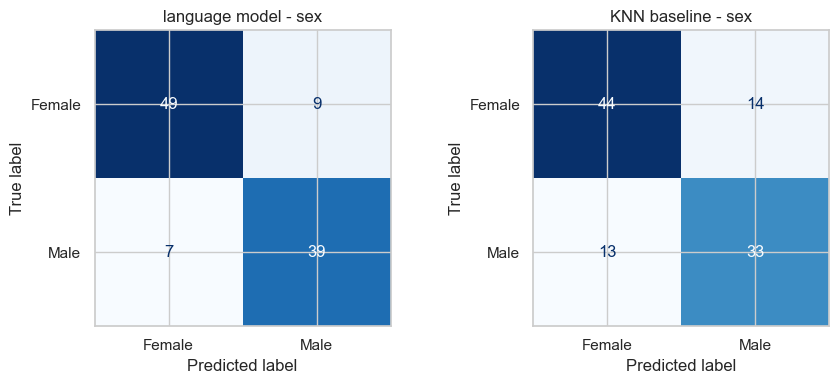

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name, pred in [(axes[0], 'language model', lm_pred), (axes[1], 'KNN baseline', knn_pred)]:
    ConfusionMatrixDisplay.from_predictions(
        truth, pred, labels=sex_levels, ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{name} - {target_col}')
plt.tight_layout()
plt.show()

## Downstream utility: does the imputed `sex` help predict `species`?

Reconstruction accuracy is one axis; the other is whether the filled column is *useful*. A
RandomForest predicts the held-out `species` from `{bill_length_mm, …, island, sex}`, and we compare
four versions of the `sex` column — the original (oracle), the LM's, KNN's, and a naive mode-fill —
by 5-fold stratified cross-validation, against a no-`sex` floor.

In [7]:
mode_sex = corrupt[target_col].fillna(corrupt[target_col].mode()[0])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def downstream_acc(sex_values: object) -> float:
    X = penguins[NUM].copy()
    X['island'] = penguins['island']
    X['sex'] = np.asarray(sex_values)
    X[['island', 'sex']] = OrdinalEncoder().fit_transform(X[['island', 'sex']])
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
    return float(cross_val_score(rf, X, y_species, cv=cv, scoring='accuracy').mean())


def no_sex_acc() -> float:
    X = penguins[NUM].copy()
    X['island'] = OrdinalEncoder().fit_transform(penguins[['island']])
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
    return float(cross_val_score(rf, X, y_species, cv=cv, scoring='accuracy').mean())


versions = {
    'oracle (true sex)': penguins[target_col],
    'LM-imputed': lm_filled[target_col],
    'KNN-imputed': knn_filled[target_col],
    'mode-fill': mode_sex,
}
accs = {name: downstream_acc(v) for name, v in versions.items()}
no_sex = no_sex_acc()
print(f'predicting `species` - RF 5-fold CV accuracy (no-sex floor {no_sex:.3f}):')
for name, a in accs.items():
    print(f'  {name:18} {a:.3f}')

predicting `species` - RF 5-fold CV accuracy (no-sex floor 0.982):
  oracle (true sex)  0.994
  LM-imputed         0.991
  KNN-imputed        0.988
  mode-fill          0.982


## Better reconstruction → better downstream

The four `sex` versions line up by reconstruction quality: the closer the fill is to the truth, the
more it lifts `species` accuracy above the no-`sex` floor. The margin is small — `species` is already
nearly determined by the measurements and `island` — but it is ordered, and the language model's
sharper reconstruction sits above KNN's.

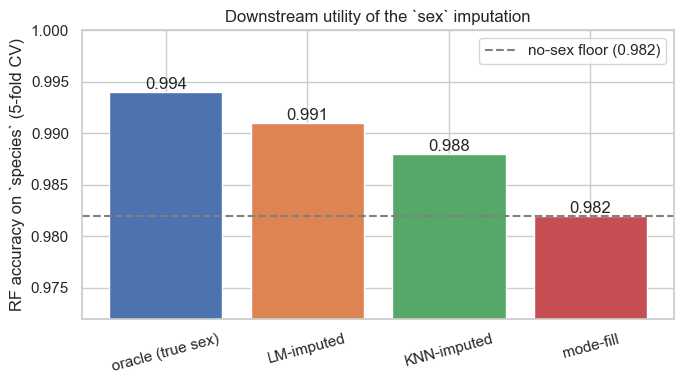

In [8]:
order = ['oracle (true sex)', 'LM-imputed', 'KNN-imputed', 'mode-fill']
vals = [accs[k] for k in order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, vals, color=['#4c72b0', '#dd8452', '#55a868', '#c44e52'])
ax.axhline(no_sex, ls='--', color='grey', label=f'no-sex floor ({no_sex:.3f})')
ax.bar_label(bars, fmt='%.3f')
ax.set_ylabel('RF accuracy on `species` (5-fold CV)')
ax.set_ylim(min(vals + [no_sex]) - 0.01, 1.0)
ax.set_title('Downstream utility of the `sex` imputation')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## What this shows

When a categorical column is genuinely reconstructible from the others — here `sex` from morphometry
and `island`, with the dataset's natural target `species` held out — the `LanguageModelImputer`
recovers it well above the majority floor and ahead of `KNNImputer`, because scoring each level under
the fitted joint `p(sex | the rest)` keeps the categorical structure that KNN loses when it
ordinal-encodes and rounds. That reconstruction quality carries downstream: a better-filled `sex`
predicts the held-out `species` more accurately, in order of reconstruction quality, though the
margin is small because `species` is already nearly determined by the measurements and `island`. The
same mechanism that ranks `classes_` in the classifier fills a missing categorical cell here.